# OSM roads — Bogotá

This notebook downloads the roads (highway) from OpenStreetMap (OSM) for Bogotá, filters the categories of interest, sorts them by priority, and assigns noise levels from the Bogotá diurnal noise zone polygons (`bogota_totaldiurnoord.geojson`).

The spatial join uses a polygon-intersection approach: each OSM road segment is matched to the noise zone it intersects; unmatched segments fall back to `sjoin_nearest`. Only daytime (diurno) noise is available for Bogotá, so `noise_evening` and `noise_night` are set equal to `noise_day`.

Finally, it saves all the data into a CSV.

In [2]:
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Import and analyse noise dataset

In [3]:
import os

# Build path relative to this notebook's location, regardless of kernel working directory
_notebook_dir = os.path.dirname(os.path.abspath(os.getcwd()))
_noise_path = os.path.join(_notebook_dir, "layers", "bogota_totaldiurnoord.geojson")
print("Loading noise data from:", _noise_path)

noise_zones = gpd.read_file(_noise_path)
noise_zones = noise_zones.to_crs("EPSG:3116")  # MAGNA-SIRGAS / Colombia Bogota zone (projected, metre-based)
print(noise_zones.crs)
print(noise_zones.shape)
print(noise_zones[['ruleid', 'rango', 'db_lo', 'db_hi']].to_string())

Loading noise data from: c:\Users\giofo\Desktop\ARCHIVIO\MASTERS\MACAD\2_MACAD\0_MACAD DRIVE\AIA\DATA ENCODING -- SUBMISSIONS\ML-Noise-Prediction\deployment\Bogotà\layers\bogota_totaldiurnoord.geojson
EPSG:3116
(11, 9)
    ruleid      rango db_lo db_hi
0        1       < 35     0    35
1        2  35.1 a 40    35    40
2        3  40.1 a 45    40    45
3        4  45.1 a 50    45    50
4        5  50.1 a 55    50    55
5        6  55.1 a 60    55    60
6        7  60.1 a 65    60    65
7        8  65.1 a 70    65    70
8        9  70.1 a 75    70    75
9       10  75.1 a 80    75    80
10      11       80 >    80   150


## Roads - OSM

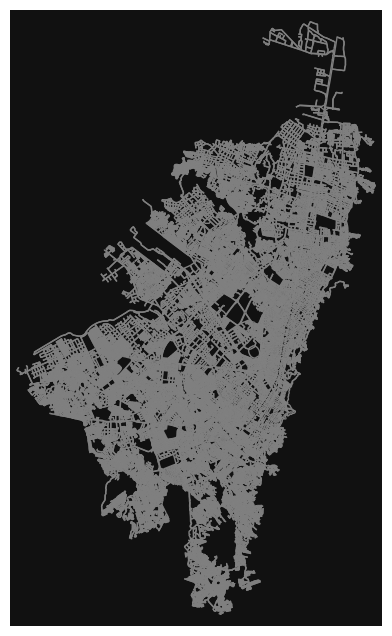

In [4]:
import osmnx as ox
G = ox.graph_from_place("Bogotá, Colombia", network_type="drive")
ox.plot_graph(G, edge_color="gray", node_size=0)
ox.save_graphml(G, "bogota.graphml")

## Prepare graph edges (roads)

In [5]:
nodes, edges = ox.graph_to_gdfs(G)

# Assign a unique segment_id to each edge based on its start and end nodes and its key
edges["segment_id"] = edges.index.map(lambda x: f"{x[0]}_{x[1]}_{x[2]}")
edges['segment_id'].head(10)

# Project edges to EPSG:3116 (MAGNA-SIRGAS / Colombia Bogota zone — projected, metre-based)
roads = edges[edges.geometry.type == 'LineString'].to_crs("EPSG:3116")
roads.to_file("bgt_osmnx_edges.gpkg", layer="edges", driver="GPKG")

## Check features completeness

In [6]:
print("Checking width..")
print(roads['width'].value_counts(dropna=False))
print("Checking maxspeed..")
print(roads['maxspeed'].value_counts(dropna=False))
print("Checking public_transport..")
print(roads['lanes'].value_counts(dropna=False))
print("Checking oneway..")
print(roads['oneway'].value_counts(dropna=False))

Checking width..
width
NaN        147984
6             125
4              78
5              30
3              13
6.5            12
6.3            12
11             10
3.9             8
7               6
4.2             4
4.1             4
[6, 30]         2
6.8             2
4.15            2
3.5             2
5.4             1
2               1
4.7             1
9.9             1
Name: count, dtype: int64
Checking maxspeed..
maxspeed
NaN                 121394
30                   24851
60                     625
20                     489
50                     485
40                     364
10                      18
[30, 50]                14
[60, 30]                12
[60, 50]                10
[30, 20]                 9
[30, 40]                 9
c                        5
35                       3
[10, 30]                 2
39                       2
[50, 40]                 2
[20, 30, 50, 40]         1
[60, 40]                 1
[40, 20]                 1
[20, 40]              

## Transform oneway from string to int

In [7]:
# osmnx returns oneway as bool (True/False); convert to int (1/0)
roads['oneway'] = roads['oneway'].astype(int)

## Filter roads categories

In [8]:
# Filter to only primary and secondary roads
categories = ['living_street','residential','primary','secondary','tertiary','trunk']
roads_filtered = roads[roads['highway'].isin(categories)]
print(f"Original: {len(roads)}, Filtered: {len(roads_filtered)}")

Original: 148298, Filtered: 146019


## Subsample to 30 000 segments (stratified by road category)

In [9]:
MAX_SEGMENTS = 30_000

if len(roads_filtered) > MAX_SEGMENTS:
    total = len(roads_filtered)
    parts = []
    for cat in categories:
        group = roads_filtered[roads_filtered['highway'] == cat]
        if len(group) == 0:
            continue
        n = max(1, round(MAX_SEGMENTS * len(group) / total))
        parts.append(group.sample(n=min(n, len(group)), random_state=42))
    roads_filtered = gpd.GeoDataFrame(pd.concat(parts), crs=roads_filtered.crs)
    if len(roads_filtered) > MAX_SEGMENTS:
        roads_filtered = roads_filtered.sample(n=MAX_SEGMENTS, random_state=42)

print(f"roads_filtered after subsampling: {len(roads_filtered)}")
print(roads_filtered['highway'].value_counts())

roads_filtered after subsampling: 30000
highway
residential      23138
tertiary          4422
secondary         1357
primary            732
trunk              350
living_street        1
Name: count, dtype: int64


## Plot road categories distribution

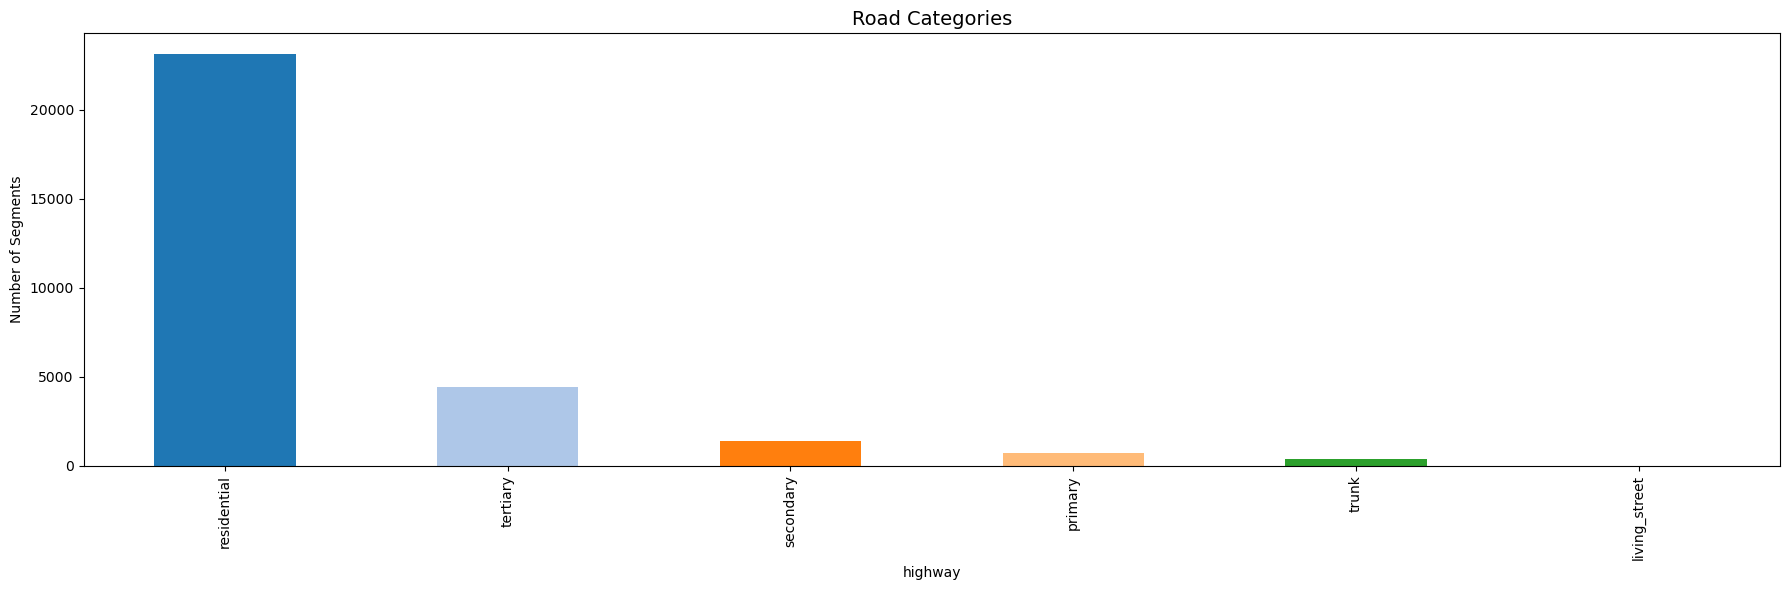

In [10]:
fig, axes = plt.subplots(1, 1, figsize=(18, 6))

class_count = roads_filtered['highway'].value_counts()

class_count.plot(kind='bar', ax=axes, color=plt.cm.tab20.colors[:len(class_count)])
axes.set_title("Road Categories", fontsize=14)
axes.set_ylabel("Number of Segments")
axes.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


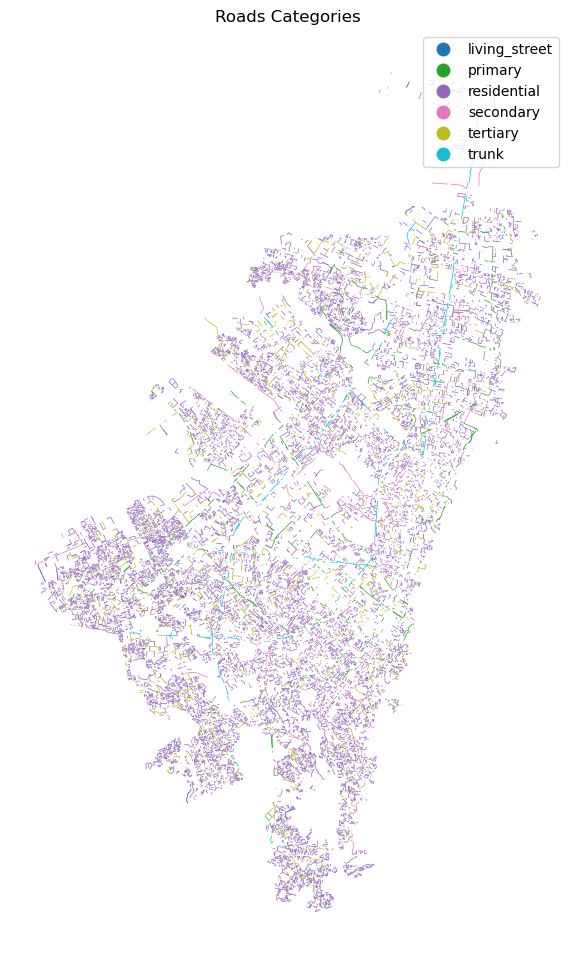

In [11]:
ax = roads_filtered.plot(column='highway', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Roads Categories')
ax.set_axis_off()

## Assign to each reoad segment the closest noise value

In [ ]:
noise_cols = ['ruleid', 'rango', 'db_lo', 'db_hi', 'geometry']

# Step 1: assign noise zone to each road via polygon intersection
noise_roads = gpd.sjoin(
    roads_filtered,
    noise_zones[noise_cols],
    how='left',
    predicate='intersects'
)
noise_roads['distance_to_zone'] = 0.0

# Step 2: for roads that didn't intersect any zone, fall back to nearest zone
unmatched_mask = noise_roads['ruleid'].isna()
unmatched = roads_filtered.loc[noise_roads[unmatched_mask].index].copy()
unmatched = unmatched[~unmatched.index.duplicated()]

if len(unmatched) > 0:
    nearest = gpd.sjoin_nearest(
        unmatched,
        noise_zones[noise_cols],
        how='left',
        distance_col='distance_to_zone'
    )
    # Replace unmatched rows with nearest results
    noise_roads = noise_roads[~unmatched_mask]
    noise_roads = pd.concat([noise_roads, nearest])

# Deduplicate: one noise zone per road segment (keep closest / first match)
noise_roads = noise_roads.sort_values('distance_to_zone').loc[~noise_roads.index.duplicated(keep='first')]

print(f"Filtered roads: {len(roads_filtered)}, After join: {len(noise_roads)}")
print(f"Roads without noise zone: {noise_roads['ruleid'].isna().sum()}")

## Convert noise to numerical features

In [ ]:
def extract_db(row):
    """Return representative dB value from a noise zone row.
    Uses the lower bound of the range to match the Barcelona convention,
    except for the '< 35' zone where db_lo=0 and we use db_hi instead."""
    lo = float(row['db_lo'])
    hi = float(row['db_hi'])
    if lo == 0:     # "< 35" zone
        return int(hi)
    if hi >= 150:   # "80 >" zone
        return int(lo)
    return int(lo)

# Bogotá only has diurno (daytime) noise — evening and night are set equal to day
noise_roads['noise_day'] = noise_roads.apply(extract_db, axis=1)
noise_roads['noise_evening'] = noise_roads['noise_day']
noise_roads['noise_night'] = noise_roads['noise_day']

print("noise_day distribution:")
print(noise_roads['noise_day'].value_counts().sort_index())

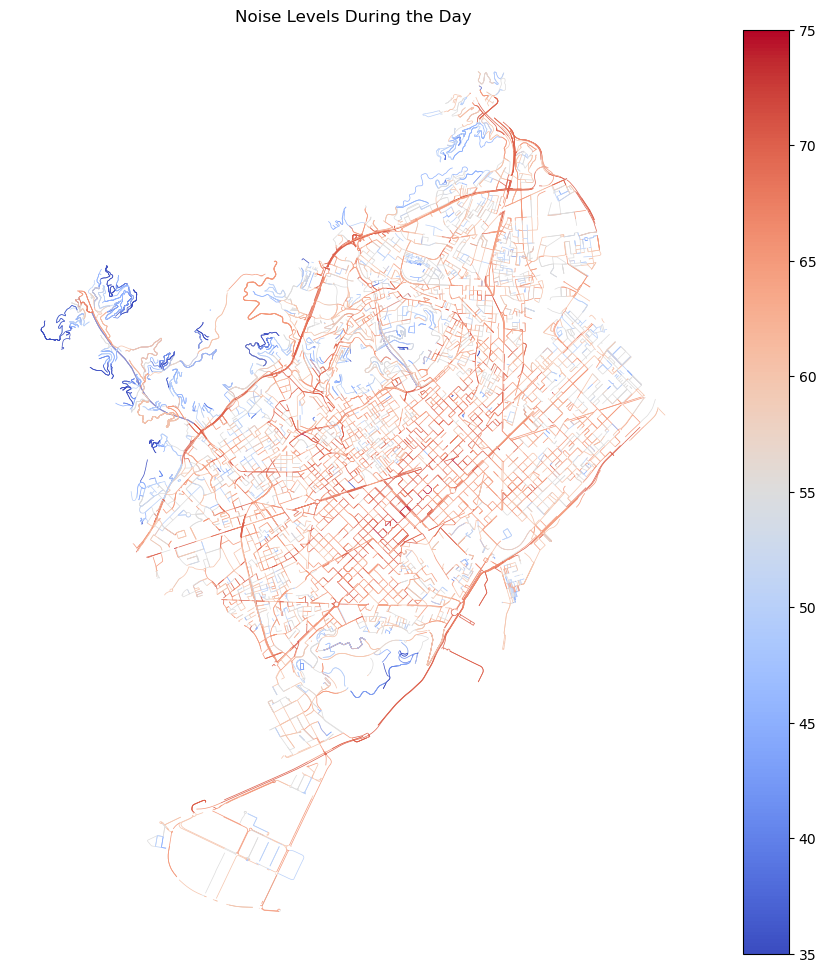

In [13]:
noise_roads['noise_day'] = noise_roads['noise_day']
ax = noise_roads.plot(cmap="coolwarm", column='noise_day', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Noise Levels During the Day')
ax.set_axis_off()

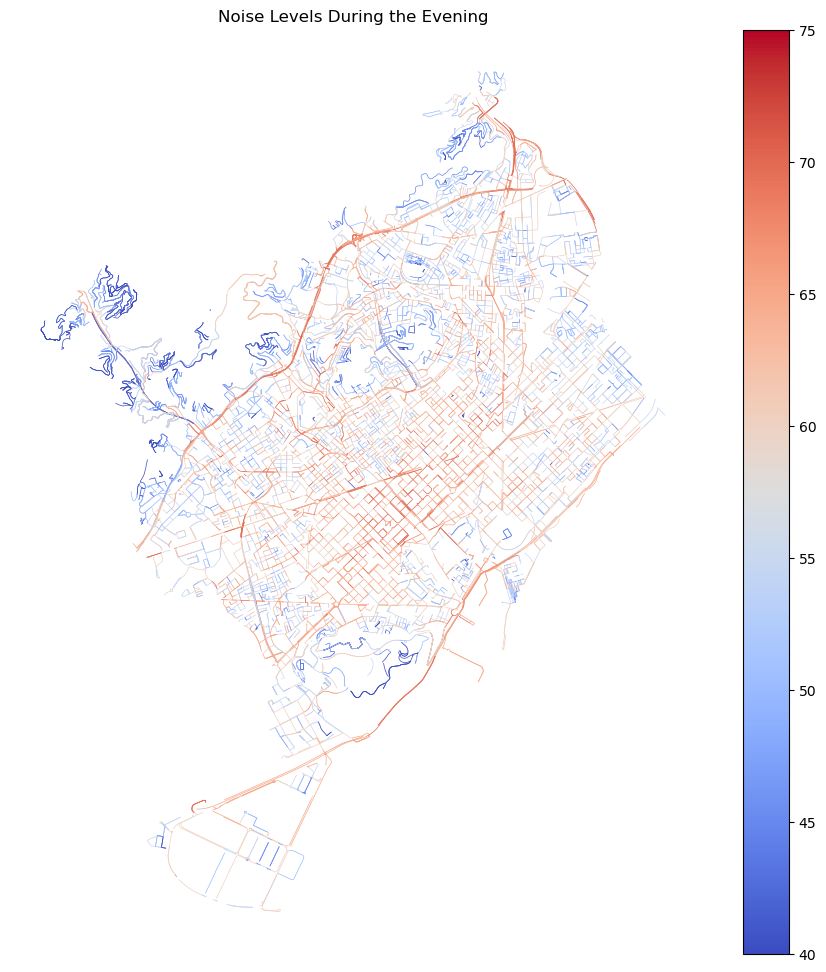

In [14]:
noise_roads['noise_evening'] = noise_roads['noise_evening']
ax = noise_roads.plot(cmap="coolwarm", column='noise_evening', linewidth=0.5, legend=True, figsize=(12, 12), vmin=40, vmax=75)
ax.set_title('Noise Levels During the Evening')
ax.set_axis_off()

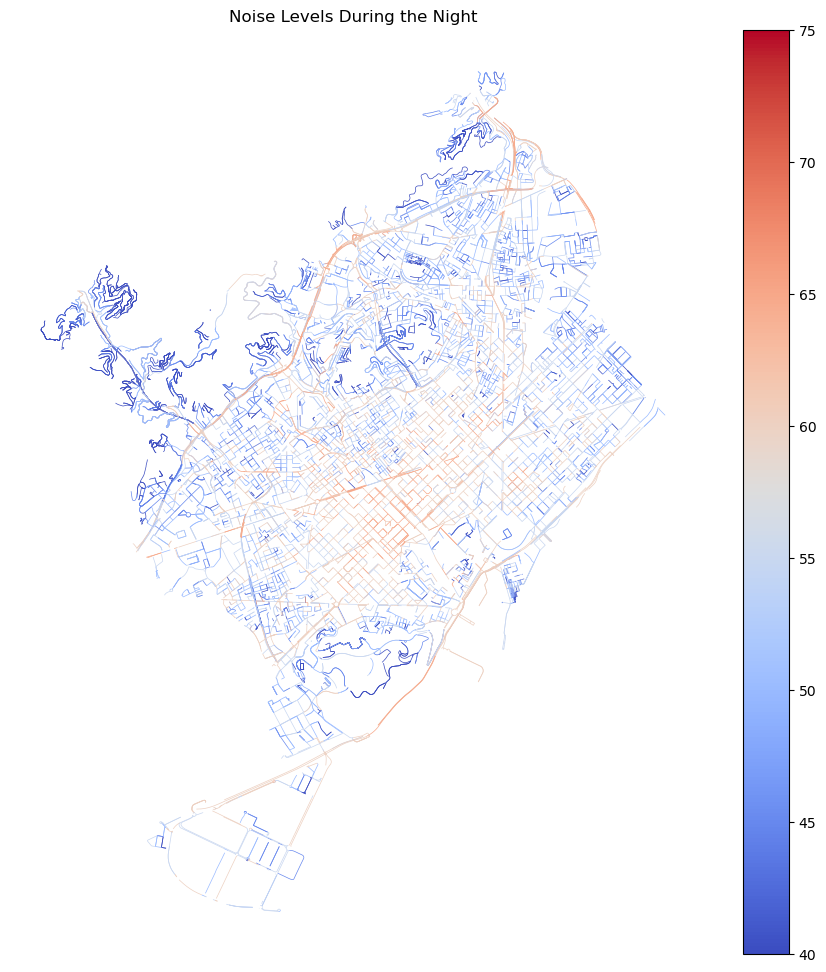

In [15]:
noise_roads['noise_night'] = noise_roads['noise_night']
ax = noise_roads.plot(cmap="coolwarm", column='noise_night', linewidth=0.5, legend=True, figsize=(12, 12),  vmin=40, vmax=75)
ax.set_title('Noise Levels During the Night')
ax.set_axis_off()

## Convert category to numerical feature

In [16]:
noise_roads['road_category'] = noise_roads['highway']
noise_roads['road_category'].value_counts()

road_category
residential      8247
tertiary         2524
living_street    2118
secondary        1419
primary           624
trunk             217
Name: count, dtype: int64

In [17]:
category_map = {
    'trunk': 1,
    'primary': 2,
    'secondary': 3,
    'tertiary': 4,
    'residential': 5,
    'living_street': 6
}

noise_roads['category_code'] = noise_roads['highway'].map(category_map)
noise_roads.head()

osmid      highway lanes maxspeed  \
u           v         key                                                       
13845167536 847716886 0    [1449373108, 71213823]  residential   NaN       30   
21638869    30343583  0                   4809729  residential   NaN       30   
            242318729 0                   4079509     tertiary     2       30   
            30343672  0                   4079509     tertiary     2       30   
3055187877  431100338 0    [900167872, 900167871]  residential   NaN       30   

                                              name  oneway reversed  \
u           v         key                                             
13845167536 847716886 0     Carrer d'Albert Llanas       0    False   
21638869    30343583  0    Carrer de Grau i Torras       0    False   
            242318729 0    Carrer de Pepe Rubianes       0     True   
            30343672  0    Carrer de Pepe Rubianes       0    False   
3055187877  431100338 0         Carrer de Copèrnic       0    False   

                               length  \
u           v         key               
13845167536 847716886 0    401.507724   
21638869    30343583  0     90.400969   
            242318729 0     15.026538   
            30343672  0     15.374932   
3055187877  431100338 0     46.078887   

                                                                    geometry  \
u           v         key                                                      
13845167536 847716886 0    LINESTRING (429520.922 4585357.367, 429528.093...   
21638869    30343583  0    LINESTRING (432323.988 4581101.635, 432322.203...   
            242318729 0    LINESTRING (432323.988 4581101.635, 432309.474...   
            30343672  0    LINESTRING (432323.988 4581101.635, 432338.836...   
3055187877  431100338 0    LINESTRING (428285.093 4583684.318, 428281.562...   

                          access  ...     PATIS_E geometry_type   start  \
u           v         key         ...                                     
13845167536 847716886 0      NaN  ...  < 40 dB(A)          Line  429619   
21638869    30343583  0      NaN  ...  < 40 dB(A)          Line  432298   
            242318729 0      NaN  ...  < 40 dB(A)          Line  432298   
            30343672  0      NaN  ...  < 40 dB(A)          Line  432333   
3055187877  431100338 0      NaN  ...  < 40 dB(A)          Line  428242   

                              end distance noise_day noise_evening  \
u           v         key                                            
13845167536 847716886 0    429661      0.0        55            55   
21638869    30343583  0    432312      0.0        55            50   
            242318729 0    432323      0.0        55            55   
            30343672  0    432337      0.0        60            60   
3055187877  431100338 0    428283      0.0        60            60   

                          noise_night  road_category category_code  
u           v         key                                           
13845167536 847716886 0            50    residential             5  
21638869    30343583  0            50    residential             5  
            242318729 0            50       tertiary             4  
            30343672  0            55       tertiary             4  
3055187877  431100338 0            55    residential             5  

[5 rows x 54 columns]

## Calculate distance to major road

In [18]:
# Filter target roads
target_categories = ['trunk', 'primary', 'secondary' ]
target_roads = noise_roads[noise_roads['highway'].isin(target_categories)].copy()

# Ensure unique index
noise_roads = noise_roads.reset_index(drop=True)
target_roads = target_roads.reset_index(drop=True)

# Drop 'index_right' if it exists to avoid conflicts with sjoin_nearest
if 'index_right' in noise_roads.columns:
    noise_roads = noise_roads.drop(columns=['index_right'])

# Spatial join: each noise road gets its nearest target road (no duplication)
noise_roads = noise_roads.sjoin_nearest(
    target_roads[['geometry']], how='left', distance_col='dist_to_main'
)
noise_roads.fillna(0) #fillna(0) to replace any NaN values with 0
noise_roads = noise_roads.drop_duplicates(subset='segment_id', keep='first')
noise_roads.head()

,osmid,highway,lanes,maxspeed,name,oneway,reversed,length,geometry,access,...,start,end,distance,noise_day,noise_evening,noise_night,road_category,category_code,index_right,dist_to_main
0,"[1449373108, 71213823]",residential,NaN,30,Carrer d'Albert Llanas,0,False,401.507724,"LINESTRING (429520.922 4585357.367, 429528.093...",NaN,...,429619,429661,0.0,55,55,50,residential,5,1507,258.681126
1,4809729,residential,NaN,30,Carrer de Grau i Torras,0,False,90.400969,"LINESTRING (432323.988 4581101.635, 432322.203...",NaN,...,432298,432312,0.0,55,50,50,residential,5,377,429.190460
2,4079509,tertiary,2,30,Carrer de Pepe Rubianes,0,True,15.026538,"LINESTRING (432323.988 4581101.635, 432309.474...",NaN,...,432298,432323,0.0,55,55,50,tertiary,4,377,512.333789
3,4079509,tertiary,2,30,Carrer de Pepe Rubianes,0,False,15.374932,"LINESTRING (432323.988 4581101.635, 432338.836...",NaN,...,432333,432337,0.0,60,60,55,tertiary,4,377,516.423077
4,"[900167872, 900167871]",residential,NaN,30,Carrer de Copèrnic,0,False,46.078887,"LINESTRING (428285.093 4583684.318, 428281.562...",NaN,...,428242,428283,0.0,60,60,55,residential,5,179,214.041852


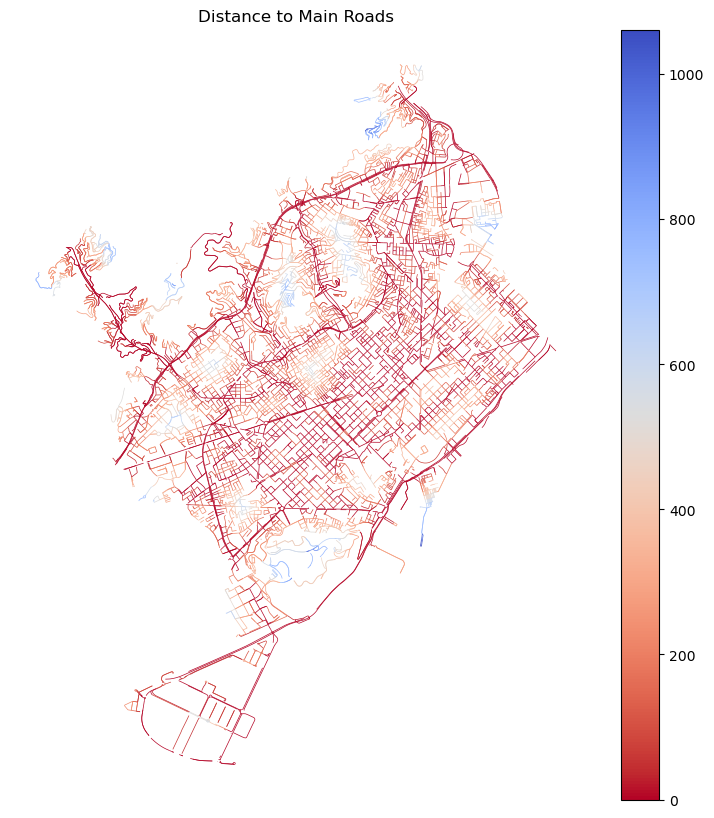

In [19]:
# Plot Distance to Main Roads
ax = noise_roads.plot(column='dist_to_main', cmap='coolwarm_r', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Distance to Main Roads')
ax.set_axis_off()

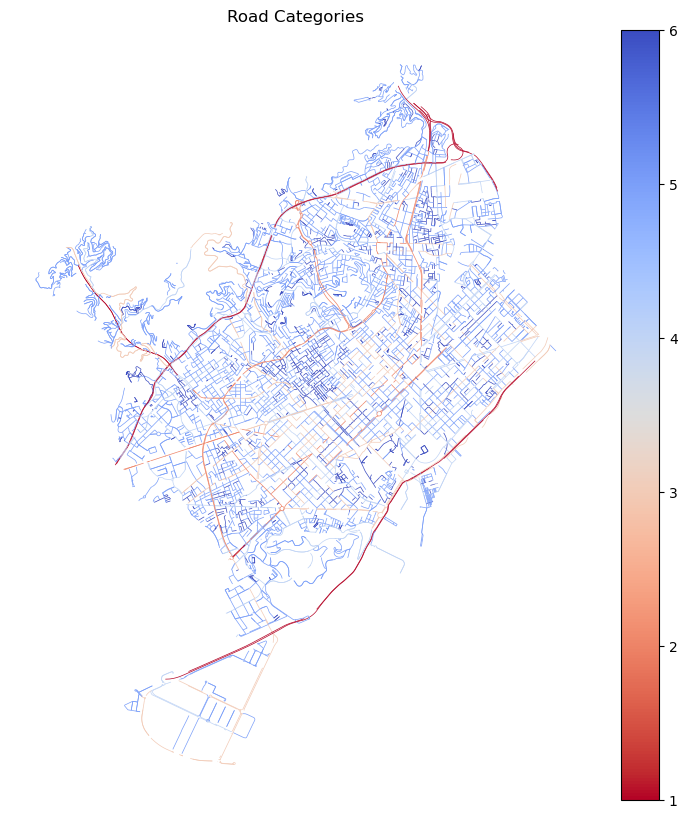

In [20]:
# Plot Road Categories
ax = noise_roads.plot(column='category_code', cmap='coolwarm_r', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Road Categories')
ax.set_axis_off()

In [21]:
noise_roads.head()

,osmid,highway,lanes,maxspeed,name,oneway,reversed,length,geometry,access,...,start,end,distance,noise_day,noise_evening,noise_night,road_category,category_code,index_right,dist_to_main
0,"[1449373108, 71213823]",residential,NaN,30,Carrer d'Albert Llanas,0,False,401.507724,"LINESTRING (429520.922 4585357.367, 429528.093...",NaN,...,429619,429661,0.0,55,55,50,residential,5,1507,258.681126
1,4809729,residential,NaN,30,Carrer de Grau i Torras,0,False,90.400969,"LINESTRING (432323.988 4581101.635, 432322.203...",NaN,...,432298,432312,0.0,55,50,50,residential,5,377,429.190460
2,4079509,tertiary,2,30,Carrer de Pepe Rubianes,0,True,15.026538,"LINESTRING (432323.988 4581101.635, 432309.474...",NaN,...,432298,432323,0.0,55,55,50,tertiary,4,377,512.333789
3,4079509,tertiary,2,30,Carrer de Pepe Rubianes,0,False,15.374932,"LINESTRING (432323.988 4581101.635, 432338.836...",NaN,...,432333,432337,0.0,60,60,55,tertiary,4,377,516.423077
4,"[900167872, 900167871]",residential,NaN,30,Carrer de Copèrnic,0,False,46.078887,"LINESTRING (428285.093 4583684.318, 428281.562...",NaN,...,428242,428283,0.0,60,60,55,residential,5,179,214.041852


## Create data frame

In [ ]:
dataset = pd.DataFrame({
    "road_id": noise_roads['segment_id'],
    "noise_day": noise_roads['noise_day'],
    "noise_evening": noise_roads['noise_evening'],
    "noise_night": noise_roads['noise_night'],
    "road_length": noise_roads['geometry'].length,
    "road_category": noise_roads['category_code'],
    "dist_to_main": noise_roads['dist_to_main'],
}).fillna(0)
dataset = dataset.drop_duplicates(subset='road_id', keep='first')
dataset.head()

## Check correlation with noise

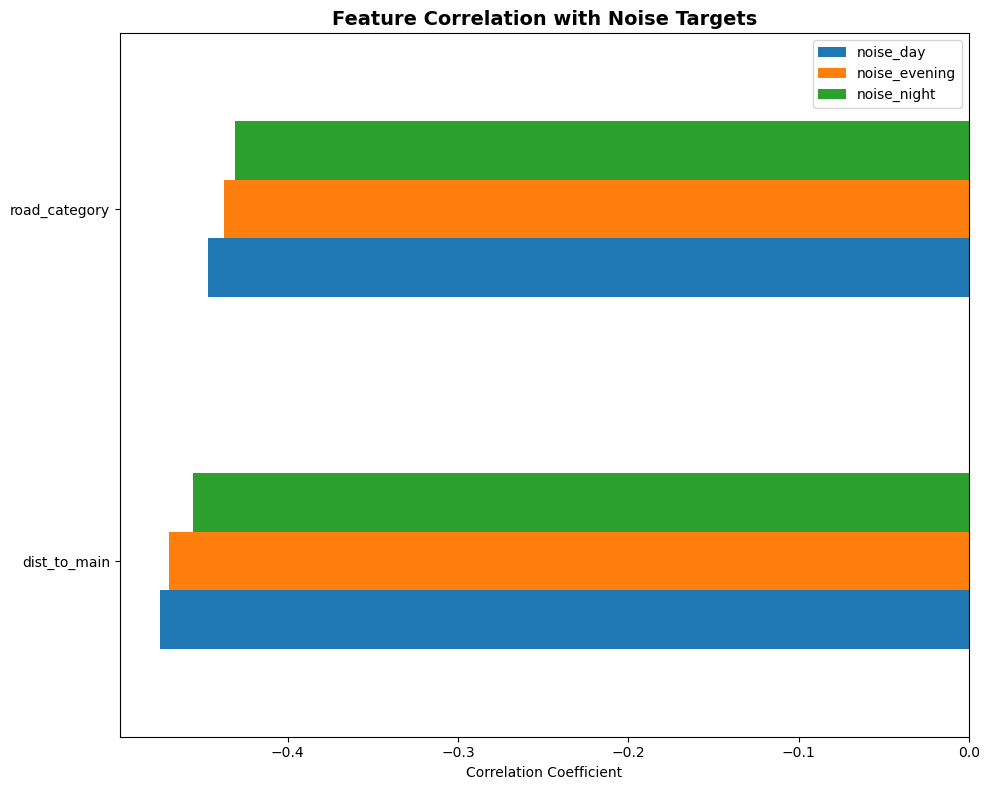

               noise_day  noise_evening  noise_night
road_category  -0.446783      -0.437545    -0.431164
dist_to_main   -0.474769      -0.469922    -0.455504


In [23]:
# Extract correlations with noise predictions
dataset_filtered = dataset[['noise_day', 'noise_evening', 'noise_night','dist_to_main','road_category']]
target_cols = ['noise_day', 'noise_evening', 'noise_night']
feature_correlation = dataset_filtered.corr(method = 'spearman')[target_cols].drop(target_cols)

# Sort by absolute correlation
feature_correlation_sorted = feature_correlation.abs().sort_values('noise_day', ascending=False)

# Plot bar chart
fig, ax = plt.subplots(figsize=(10, 8))
feature_correlation.loc[feature_correlation_sorted.index].plot(kind='barh', ax=ax)
ax.set_title('Feature Correlation with Noise Targets', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print(feature_correlation.sort_values('noise_day', ascending=False))

## Export dataset to CSV

In [24]:
import os
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "osm_roads_features.csv"), index=False)
print("Exported osm_roads_features.csv")

Exported osm_roads_features.csv
